# Tech Challenge Fase 01 — Modelagem e Comparação

Treinamento dos baselines (Scikit-Learn) e da rede neural MLP (PyTorch), comparação com ≥4 métricas e análise de custo de negócio.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

from src.data.loader import load_raw, get_features_target
from src.data.preprocessing import build_pipeline, split_data, to_numpy
from src.models.baseline import BASELINES, train_baselines
from src.models.mlp import ChurnMLP
from src.models.trainer import train_mlp, predict_proba
from src.evaluation.metrics import evaluate_model, cost_analysis, comparison_table
from src.config import SEED

plt.rcParams['figure.figsize'] = (10, 5)

## 1. Preparação dos Dados

In [2]:
df = load_raw('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
X, y = get_features_target(df)

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

pipeline = build_pipeline()
X_train_t = to_numpy(pipeline.fit_transform(X_train))
X_val_t   = to_numpy(pipeline.transform(X_val))
X_test_t  = to_numpy(pipeline.transform(X_test))

y_train_np = y_train.to_numpy()
y_val_np   = y_val.to_numpy()
y_test_np  = y_test.to_numpy()

print(f'Treino: {X_train_t.shape} | Val: {X_val_t.shape} | Teste: {X_test_t.shape}')
print(f'Input dim para MLP: {X_train_t.shape[1]}')

Treino: (4929, 46) | Val: (705, 46) | Teste: (1409, 46)
Input dim para MLP: 46


## 2. Baselines (Scikit-Learn)

In [3]:
baseline_cv = train_baselines(X_train_t, y_train_np)
print('CV results (média 5-fold):')
pd.DataFrame(baseline_cv).T.round(4)

CV results (média 5-fold):


,roc_auc,pr_auc,f1,accuracy
dummy,0.5000,0.2654,0.0000,0.7346
logistic_regression,0.8431,0.6542,0.5899,0.8008
random_forest,0.8144,0.5939,0.5252,0.7778
gradient_boosting,0.8423,0.6580,0.5742,0.7971


## 3. MLP com PyTorch

In [4]:
input_dim = X_train_t.shape[1]
mlp = ChurnMLP(input_dim=input_dim)

history = train_mlp(
    model=mlp,
    X_train=X_train_t, y_train=y_train_np,
    X_val=X_val_t,   y_val=y_val_np,
    epochs=100, lr=1e-3, batch_size=64, patience=10,
)

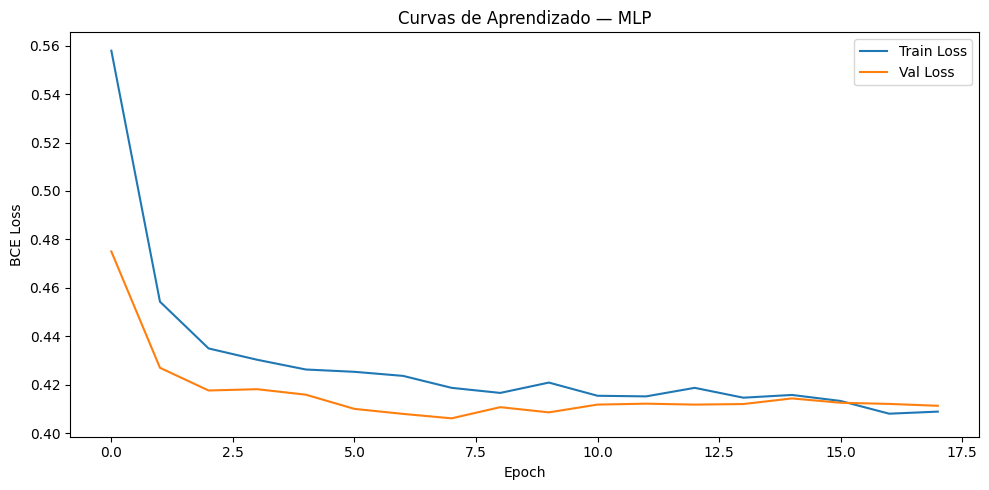

In [5]:
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'],   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Curvas de Aprendizado — MLP')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Avaliação no Conjunto de Teste

In [6]:
all_results = {}
all_probas  = {}

# Baselines
for name, clf in BASELINES.items():
    proba = clf.predict_proba(X_test_t)[:, 1] if hasattr(clf, 'predict_proba') else clf.predict(X_test_t).astype(float)
    all_probas[name]  = proba
    metrics = evaluate_model(y_test_np, proba)
    metrics['business_cost'] = cost_analysis(y_test_np, (proba >= 0.5).astype(int))
    all_results[name] = metrics

# MLP
mlp_proba = predict_proba(mlp, X_test_t)
all_probas['mlp'] = mlp_proba
mlp_metrics = evaluate_model(y_test_np, mlp_proba)
mlp_metrics['business_cost'] = cost_analysis(y_test_np, (mlp_proba >= 0.5).astype(int))
all_results['mlp'] = mlp_metrics

table = comparison_table(all_results)
print('\n=== Tabela Comparativa de Modelos ===')
table.round(4)


=== Tabela Comparativa de Modelos ===


,roc_auc,pr_auc,f1,accuracy,business_cost
model,,,,,
logistic_regression,0.8424,0.6354,0.6009,0.8048,17780.0
gradient_boosting,0.8418,0.6566,0.5783,0.8013,19180.0
mlp,0.8413,0.6319,0.5964,0.7935,17220.0
random_forest,0.8226,0.6133,0.5585,0.7857,19490.0
dummy,0.5000,0.2654,0.0000,0.7346,37400.0


## 5. Curvas ROC e Precision-Recall

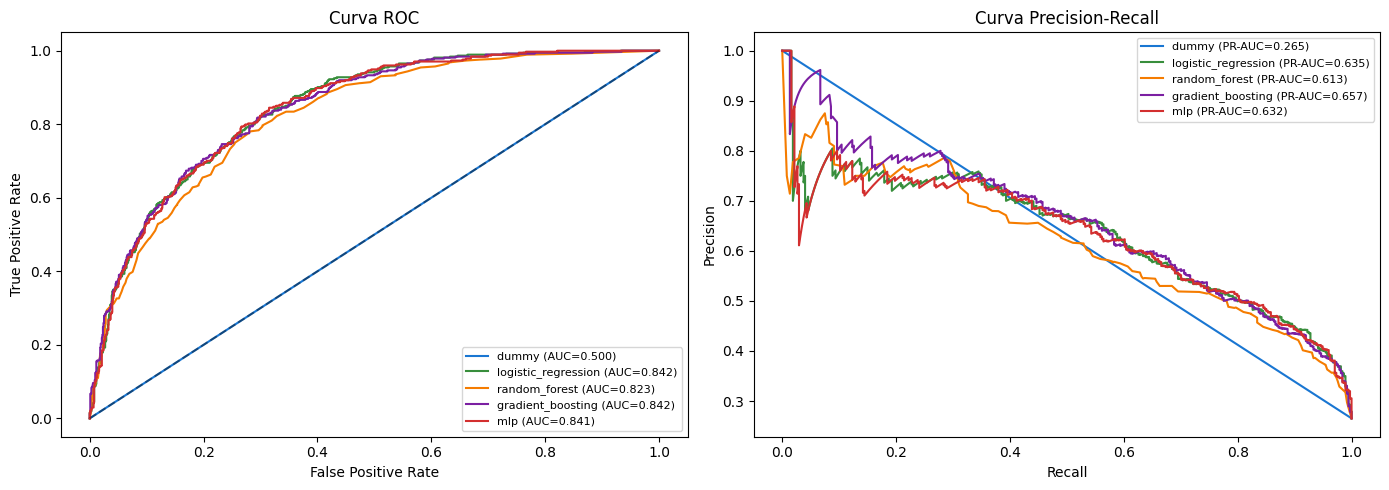

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2', '#D32F2F']

for (name, proba), color in zip(all_probas.items(), colors):
    fpr, tpr, _ = roc_curve(y_test_np, proba)
    auc = all_results[name]['roc_auc']
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color)

axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC')
axes[0].legend(fontsize=8)

for (name, proba), color in zip(all_probas.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test_np, proba)
    pr_auc = all_results[name]['pr_auc']
    axes[1].plot(rec, prec, label=f'{name} (PR-AUC={pr_auc:.3f})', color=color)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Análise de Custo de Negócio

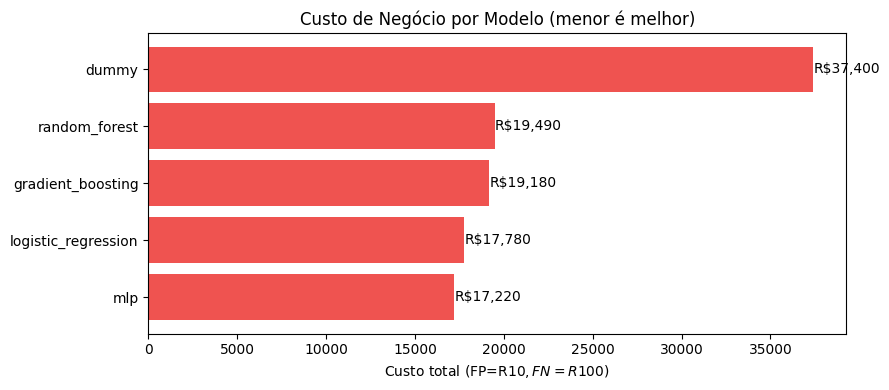


Trade-off: FN (churn não detectado) custa 10x mais que FP (retenção desnecessária)
              model  business_cost  roc_auc
                mlp        17220.0 0.841350
logistic_regression        17780.0 0.842414
  gradient_boosting        19180.0 0.841763
      random_forest        19490.0 0.822624
              dummy        37400.0 0.500000


In [8]:
cost_df = pd.DataFrame({
    'model': list(all_results.keys()),
    'business_cost': [v['business_cost'] for v in all_results.values()],
    'roc_auc': [v['roc_auc'] for v in all_results.values()],
}).sort_values('business_cost')

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(cost_df['model'], cost_df['business_cost'], color='#EF5350')
ax.set_xlabel('Custo total (FP=R$10, FN=R$100)')
ax.set_title('Custo de Negócio por Modelo (menor é melhor)')
for bar, val in zip(bars, cost_df['business_cost']):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'R${val:,.0f}', va='center')
plt.tight_layout()
plt.show()

print('\nTrade-off: FN (churn não detectado) custa 10x mais que FP (retenção desnecessária)')
print(cost_df[['model','business_cost','roc_auc']].to_string(index=False))

In [11]:

all_results = {}
all_probas  = {}

for name, clf in BASELINES.items():
    proba = clf.predict_proba(X_test_t)[:, 1] if hasattr(clf, 'predict_proba') else clf.predict(X_test_t).astype(float)
    all_probas[name]  = proba
    metrics = evaluate_model(y_test_np, proba)
    metrics['business_cost'] = cost_analysis(y_test_np, (proba >= 0.5).astype(int))
    all_results[name] = metrics

mlp_proba = predict_proba(mlp, X_test_t)
all_probas['mlp'] = mlp_proba
mlp_metrics = evaluate_model(y_test_np, mlp_proba)
mlp_metrics['business_cost'] = cost_analysis(y_test_np, (mlp_proba >= 0.5).astype(int))
all_results['mlp'] = mlp_metrics

table = comparison_table(all_results)
print(table.round(4).to_string())


                     roc_auc  pr_auc      f1  accuracy  business_cost
model                                                                
logistic_regression   0.8424  0.6354  0.6009    0.8048        17780.0
gradient_boosting     0.8418  0.6566  0.5783    0.8013        19180.0
mlp                   0.8413  0.6319  0.5964    0.7935        17220.0
random_forest         0.8226  0.6133  0.5585    0.7857        19490.0
dummy                 0.5000  0.2654  0.0000    0.7346        37400.0


In [ ]:

# Detalhamento do custo: FP e FN por modelo
print(f"{'Modelo':<25} {'FP':>6} {'FN':>6} {'Custo FP':>10} {'Custo FN':>10} {'Total':>10}")
print("-" * 70)
for name, proba in all_probas.items():
    y_pred = (proba >= 0.5).astype(int)
    fp = int(((y_pred == 1) & (y_test_np == 0)).sum())
    fn = int(((y_pred == 0) & (y_test_np == 1)).sum())
    cost = fp * 10 + fn * 100
    print(f"{name:<25} {fp:>6} {fn:>6} {fp*10:>10} {fn*100:>10} {cost:>10}")


In [12]:

import numpy as np

print(f"{'Modelo':<25} {'FP':>6} {'FN':>6} {'TP':>6} {'TN':>6} {'Custo FP':>10} {'Custo FN':>10} {'Total':>10}")
print("-" * 80)
for name, proba in all_probas.items():
    y_pred = (proba >= 0.5).astype(int)
    tp = int(((y_pred == 1) & (y_test_np == 1)).sum())
    tn = int(((y_pred == 0) & (y_test_np == 0)).sum())
    fp = int(((y_pred == 1) & (y_test_np == 0)).sum())
    fn = int(((y_pred == 0) & (y_test_np == 1)).sum())
    cost = fp * 10 + fn * 100
    print(f"{name:<25} {fp:>6} {fn:>6} {tp:>6} {tn:>6} {fp*10:>10} {fn*100:>10} {cost:>10}")

total_churn = int(y_test_np.sum())
total_no_churn = len(y_test_np) - total_churn
print(f"\nTotal clientes no teste: {len(y_test_np)} | Churn real: {total_churn} ({total_churn/len(y_test_np)*100:.1f}%) | Não-churn: {total_no_churn}")


Modelo                        FP     FN     TP     TN   Custo FP   Custo FN      Total
--------------------------------------------------------------------------------
dummy                          0    374      0   1035          0      37400      37400
logistic_regression          108    167    207    927       1080      16700      17780
random_forest                119    183    191    916       1190      18300      19490
gradient_boosting             98    182    192    937        980      18200      19180
mlp                          132    159    215    903       1320      15900      17220

Total clientes no teste: 1409 | Churn real: 374 (26.5%) | Não-churn: 1035


In [13]:

# Análise por threshold - quanto muda o custo da MLP ao ajustar o threshold?
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
print("Análise de threshold — MLP:")
print(f"{'Threshold':>10} {'FP':>6} {'FN':>6} {'TP':>6} {'Recall':>8} {'Precision':>10} {'F1':>8} {'Custo':>10}")
print("-" * 70)
for t in thresholds:
    y_pred = (mlp_proba >= t).astype(int)
    tp = int(((y_pred == 1) & (y_test_np == 1)).sum())
    fp = int(((y_pred == 1) & (y_test_np == 0)).sum())
    fn = int(((y_pred == 0) & (y_test_np == 1)).sum())
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    cost = fp * 10 + fn * 100
    print(f"{t:>10.2f} {fp:>6} {fn:>6} {tp:>6} {recall:>8.3f} {precision:>10.3f} {f1:>8.3f} {cost:>10}")


Análise de threshold — MLP:
 Threshold     FP     FN     TP   Recall  Precision       F1      Custo
----------------------------------------------------------------------
      0.30    258     94    280    0.749      0.520    0.614      11980
      0.35    233    104    270    0.722      0.537    0.616      12730
      0.40    206    116    258    0.690      0.556    0.616      13660
      0.45    164    133    241    0.644      0.595    0.619      14940
      0.50    132    159    215    0.575      0.620    0.596      17220
      0.55     96    188    186    0.497      0.660    0.567      19760
      0.60     64    220    154    0.412      0.706    0.520      22640


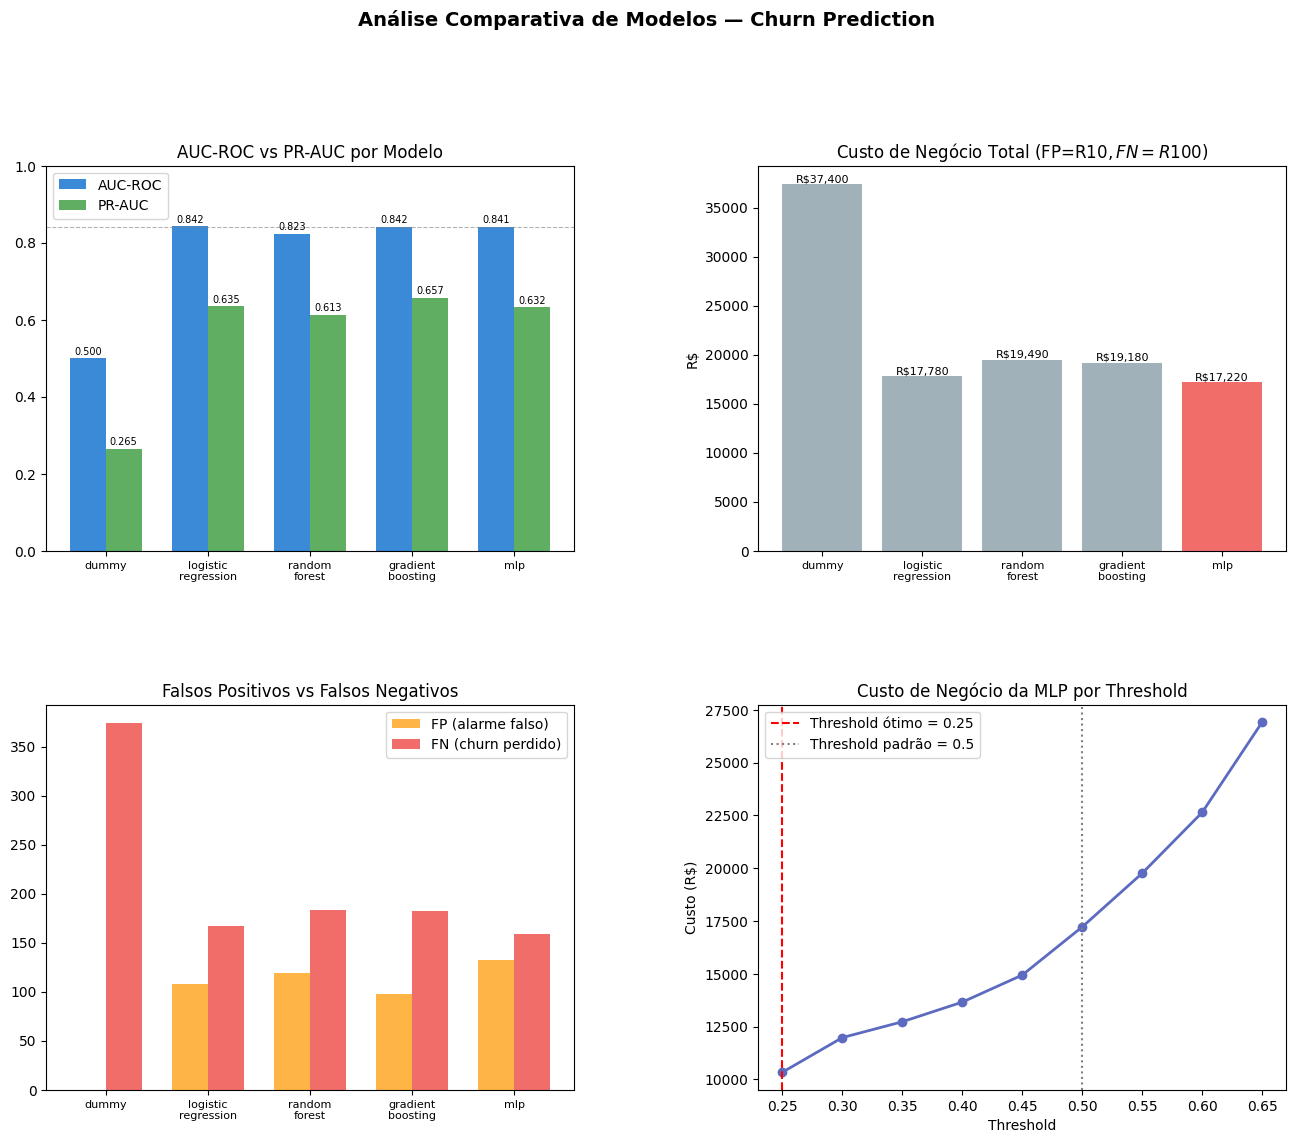

In [14]:

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# --- 1. Comparação de AUC-ROC e PR-AUC ---
ax1 = fig.add_subplot(gs[0, 0])
models = list(all_results.keys())
roc_vals  = [all_results[m]['roc_auc'] for m in models]
pr_vals   = [all_results[m]['pr_auc']  for m in models]
x = range(len(models))
width = 0.35
bars1 = ax1.bar([i - width/2 for i in x], roc_vals, width, label='AUC-ROC', color='#1976D2', alpha=0.85)
bars2 = ax1.bar([i + width/2 for i in x], pr_vals,  width, label='PR-AUC',  color='#43A047', alpha=0.85)
ax1.set_xticks(list(x)); ax1.set_xticklabels([m.replace('_','\n') for m in models], fontsize=8)
ax1.set_ylim(0, 1); ax1.set_title('AUC-ROC vs PR-AUC por Modelo'); ax1.legend()
ax1.axhline(0.84, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
for b in bars1: ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{b.get_height():.3f}', ha='center', fontsize=7)
for b in bars2: ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{b.get_height():.3f}', ha='center', fontsize=7)

# --- 2. Custo de negócio por modelo ---
ax2 = fig.add_subplot(gs[0, 1])
costs = [all_results[m]['business_cost'] for m in models]
colors_bar = ['#EF5350' if m == 'mlp' else '#90A4AE' for m in models]
bars = ax2.bar(models, costs, color=colors_bar, alpha=0.85)
ax2.set_xticklabels([m.replace('_','\n') for m in models], fontsize=8)
ax2.set_title('Custo de Negócio Total (FP=R$10, FN=R$100)'); ax2.set_ylabel('R$')
for b in bars: ax2.text(b.get_x()+b.get_width()/2, b.get_height()+200, f"R${b.get_height():,.0f}", ha='center', fontsize=8)

# --- 3. FP vs FN por modelo ---
ax3 = fig.add_subplot(gs[1, 0])
fp_vals, fn_vals = [], []
for name, proba in all_probas.items():
    y_pred = (proba >= 0.5).astype(int)
    fp_vals.append(int(((y_pred==1)&(y_test_np==0)).sum()))
    fn_vals.append(int(((y_pred==0)&(y_test_np==1)).sum()))
xm = range(len(models))
ax3.bar([i-width/2 for i in xm], fp_vals, width, label='FP (alarme falso)',   color='#FFA726', alpha=0.85)
ax3.bar([i+width/2 for i in xm], fn_vals, width, label='FN (churn perdido)', color='#EF5350', alpha=0.85)
ax3.set_xticks(list(xm)); ax3.set_xticklabels([m.replace('_','\n') for m in models], fontsize=8)
ax3.set_title('Falsos Positivos vs Falsos Negativos'); ax3.legend()

# --- 4. Custo MLP por threshold ---
ax4 = fig.add_subplot(gs[1, 1])
thresholds = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]
costs_t = []
for t in thresholds:
    y_pred = (mlp_proba >= t).astype(int)
    fp = int(((y_pred==1)&(y_test_np==0)).sum())
    fn = int(((y_pred==0)&(y_test_np==1)).sum())
    costs_t.append(fp*10 + fn*100)
ax4.plot(thresholds, costs_t, 'o-', color='#5C6BC0', linewidth=2)
best_t = thresholds[costs_t.index(min(costs_t))]
ax4.axvline(best_t, color='red', linestyle='--', label=f'Threshold ótimo = {best_t}')
ax4.axvline(0.5, color='gray', linestyle=':', label='Threshold padrão = 0.5')
ax4.set_xlabel('Threshold'); ax4.set_ylabel('Custo (R$)')
ax4.set_title('Custo de Negócio da MLP por Threshold'); ax4.legend()

plt.suptitle('Análise Comparativa de Modelos — Churn Prediction', fontsize=14, fontweight='bold', y=1.01)
plt.show()
